In [2]:
import json

data_count = []
with open('cve_analysis_count_confidence.jsonl', 'r') as file:
    for line in file:
        json_object = json.loads(line.strip())
        data_count.append(json_object)

In [3]:
t_count = 0
for record in data_count: 
    t_count += record["outdated_library"]

print(t_count)

108720


In [4]:
total_count = [0,0,0,0]
for d in data_count:
    total_count = [x + y for x, y in zip(total_count, d['outdated_score_class'])]

In [ ]:
category_dict = {}
with open('../source_data/61k_classified_apps_deberta_multi_v2_not_in_playstore.jsonl', 'r') as file:
    for line in file:
        obj = json.loads(line.strip())
        category_dict[obj['app_id']] = obj['category']
with open('./61k_app_categories_from_playstore.jsonl', 'r') as file:
    for line in file:
        obj = json.loads(line.strip())
        category_dict[obj['app_id']] = obj['genre']

In [6]:
## categorize
output_dict = {}
for d in data_count:
    try:
        category = category_dict[d['app_name']]
    except Exception as e:
        category = 'none'
        pass
    if category not in output_dict:
        output_dict[category] = d['outdated_score_class']
    else:
        output_dict[category] = [x + y for x, y in zip(output_dict[category], d['outdated_score_class'])]

In [7]:
filtered_data = {
    k: v for k, v in output_dict.items() if sum(v) >= 100
}

# Extract values while preserving order
values = list(filtered_data.values())

# Transpose lists (index-wise grouping)
restructured = list(map(list, zip(*values)))

In [8]:
restructured[0]

[129, 452, 533, 113, 773, 203, 256, 398, 51, 50, 83, 22, 42, 19, 1, 3, 1, 5, 6]

In [ ]:
full_dictionary = {}
with open('../source_data/61k_classified_apps_deberta_multi_v2_not_in_playstore.jsonl', 'r') as file:
    for line in file:
        obj = json.loads(line.strip())
        full_dictionary[obj['app_id']] = obj['category']

with open('../source_data/61k_app_categories_from_playstore.jsonl', 'r') as file:
    for line in file:
        obj = json.loads(line.strip())
        full_dictionary[obj['app_id']] = obj['genre']

In [ ]:
category_dict_not_in_playstore = {}
category_dict_from_playstore = {}

category_dict_sources = {
    "Not in Play Store": category_dict_not_in_playstore,
    "Not updated for 2+ yrs": category_dict_from_playstore,
}

app_categories = {}

with open('61k_app_installs.json', 'r') as file: 
    tmp = json.load(file)

for record in tmp:
    source_tmp = record["source"]
    app_id = record["package_name"]

    if source_tmp == "AndroZoo":
        source = "Not in Play Store"
        category_dict_not_in_playstore[record["package_name"]] = full_dictionary[record["package_name"]]
    elif source_tmp == "Play Store":
        category_dict_from_playstore[record["package_name"]] = full_dictionary[record["package_name"]]


In [ ]:
output_dict_by_source = {src: {} for src in category_dict_sources}

for src, cat_dict in category_dict_sources.items():
    output_dict_src = output_dict_by_source[src]
    for d in data_count:
        app_id = d['app_name']
        if app_id not in cat_dict:
            continue
        category = cat_dict[app_id]
        if category not in output_dict_src:
            output_dict_src[category] = d['outdated_score_class']
        else:
            output_dict_src[category] = [x + y for x, y in zip(output_dict_src[category], d['outdated_score_class'])]

In [36]:
output_dict_by_source

{'Not in Play Store': {'Productivity': [116, 110, 2851, 1503],
  'Communication': [427, 451, 9100, 5275],
  'Health & Fitness': [503, 859, 6248, 2857],
  'Lifestyle': [87, 123, 2195, 1458],
  'Tools': [704, 476, 12784, 5070],
  'Business': [182, 193, 3679, 1120],
  'House & Home': [233, 223, 5483, 4277],
  'Auto & Vehicles': [366, 401, 6581, 1974],
  'Music & Audio': [44, 51, 1160, 1279],
  'Entertainment': [45, 23, 725, 352],
  'Video Players & Editors': [77, 132, 2692, 1631],
  'Weather': [20, 2, 274, 82],
  'Photography': [38, 43, 913, 592],
  'Education': [13, 15, 468, 246],
  'Medical': [0, 0, 1, 0],
  'Maps & Navigation': [0, 0, 1, 0],
  'Puzzle': [0, 0, 0, 0]},
 'Not updated for 2+ yrs': {'Tools': [69, 596, 2329, 1599],
  'Libraries & Demo': [0, 7, 18, 19],
  'Health & Fitness': [30, 688, 1605, 641],
  'Lifestyle': [26, 370, 948, 720],
  'Communication': [25, 274, 879, 576],
  'Entertainment': [5, 44, 182, 135],
  'House & Home': [23, 152, 559, 442],
  'Productivity': [13, 133, 

In [ ]:
categories_grouped = list(dict.fromkeys(
    category
    for src in output_dict_by_source
    for category in output_dict_by_source[src]
))

print("========== categories_grouped ==========")
print(categories_grouped)


filtered_data_by_source = {
    src: [
        output_dict_by_source[src].get(category, [0, 0, 0, 0])
        for category in categories_grouped
    ]
    for src in output_dict_by_source
}

restructured_by_source = {
    src: list(map(list, zip(*values)))
    for src, values in filtered_data_by_source.items()
}

========== categories_grouped ==========
['Productivity', 'Communication', 'Health & Fitness', 'Lifestyle', 'Tools', 'Business', 'House & Home', 'Auto & Vehicles', 'Music & Audio', 'Entertainment', 'Video Players & Editors', 'Weather', 'Photography', 'Education', 'Medical', 'Maps & Navigation', 'Puzzle', 'Libraries & Demo', 'Personalization', 'Finance', 'Parenting', 'Sports', 'Travel & Local', 'Music', 'Simulation', 'Shopping', 'Books & Reference', 'Arcade', 'Action', 'Food & Drink', 'Art & Design', 'News & Magazines', 'Educational', 'Social', 'Word', 'Adventure', 'Board', 'Beauty', 'Casual', 'Card', 'Racing', 'Events']


In [80]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


HIGH severity percentage: 91.37%


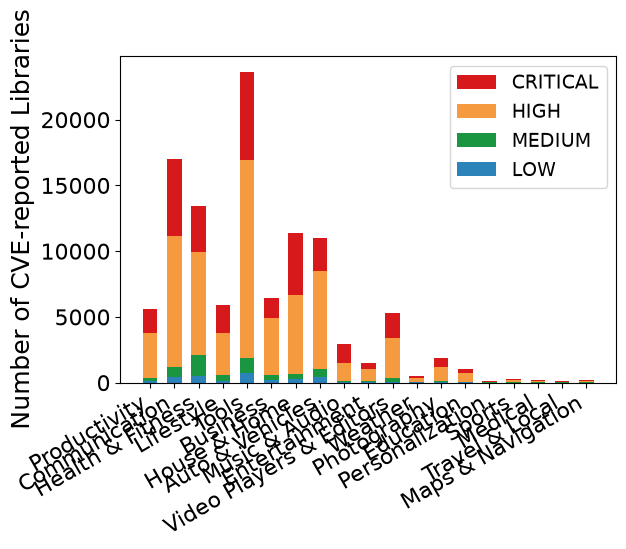

In [81]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = list(filtered_data.keys())
levels = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]

data = {
    "LOW":      restructured[0],
    "MEDIUM":   restructured[1],
    "HIGH":     restructured[2],
    "CRITICAL": restructured[3],
}
colors = {
    "CRITICAL": "#d7191c",
    "HIGH":     "#f69a3f",
    "MEDIUM":   '#1a9641',
    "LOW":      "#2b83ba",
}

width = 0.6
bottom = np.zeros(len(categories))

fig, ax = plt.subplots()
# fig.set_size_inches(12, 8)

for level, values in data.items():
    ax.bar(categories, values, width, label=level, bottom=bottom, color=colors[level])
    bottom += values

# ax.set_title("Risk Levels per Category")
handles, labels = ax.get_legend_handles_labels()
ax.set_ylabel("Number of CVE-reported Libraries")
ax.legend(handles[::-1], labels[::-1])
fig.autofmt_xdate()
plt.savefig('./plot/cve-library-count.pdf', bbox_inches='tight')

# Calculate percentage of HIGH severity
total_high = np.sum(data["HIGH"]) + np.sum(data["CRITICAL"])
total_all = sum(np.sum(values) for values in data.values())

percentage_high = (total_high / total_all) * 100

print(f"HIGH severity percentage: {percentage_high:.2f}%")


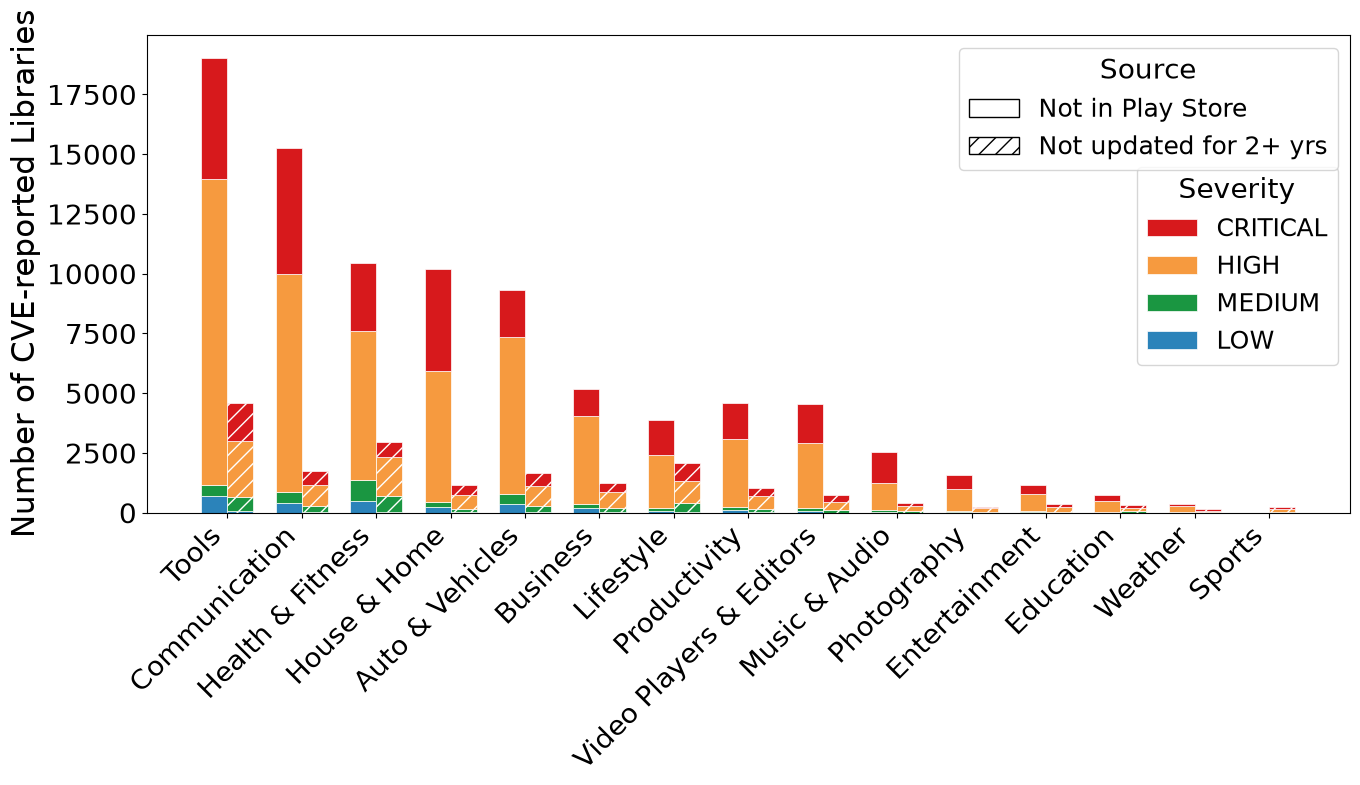

[Not in Play Store] HIGH severity percentage: 93.29%
[Not updated for 2+ yrs] HIGH severity percentage: 82.63%


In [56]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

plt.rcParams.update({
    "font.size": 20,        # Default font size
    "axes.labelsize": 22,   # Axis labels
    "xtick.labelsize": 20,  # X-axis tick labels
    "ytick.labelsize": 20,  # Y-axis tick labels
    "legend.fontsize": 18,  # Legend entries
    "legend.title_fontsize": 20,
})

# -----------------------------
# Original data
# -----------------------------
categories = list(categories_grouped)
levels = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]

# Keep the ORIGINAL keys used by restructured_by_source
sources = ["Not in Play Store", "Not updated for 2+ yrs"]

# Labels shown in the legend
# source_labels = {
#     "Not in Play Store": "Not in Play Store",
#     "In Play Store": "Not updated for 2+ yrs",
# }

colors = {
    "CRITICAL": "#d7191c",
    "HIGH": "#f69a3f",
    "MEDIUM": "#1a9641",
    "LOW": "#2b83ba",
}

# -----------------------------
# Build data from ORIGINAL arrays
# -----------------------------
data_by_source = {
    src: {
        "LOW": np.array(restructured_by_source[src][0]),
        "MEDIUM": np.array(restructured_by_source[src][1]),
        "HIGH": np.array(restructured_by_source[src][2]),
        "CRITICAL": np.array(restructured_by_source[src][3]),
    }
    for src in sources
}

# -----------------------------
# Compute Top-15 categories
# -----------------------------
total_counts = np.zeros(len(categories))

for src in sources:
    for level in levels:
        total_counts += data_by_source[src][level]

top_n = 15
top_idx = np.argsort(total_counts)[::-1][:top_n]

# Filter categories
categories_top = [categories[i] for i in top_idx]

# Filter data
filtered_data = {
    src: {
        level: data_by_source[src][level][top_idx]
        for level in levels
    }
    for src in sources
}

# -----------------------------
# Plot
# -----------------------------
x = np.arange(len(categories_top))
bar_width = 0.35

offsets = {
    sources[0]: -bar_width / 2,
    sources[1]:  bar_width / 2,
}

hatches = {
    sources[0]: "",
    sources[1]: "//",
}

fig, ax = plt.subplots(figsize=(14, 8))

for src in sources:
    bottom = np.zeros(len(categories_top))

    for level in levels:
        values = filtered_data[src][level]

        ax.bar(
            x + offsets[src],
            values,
            bar_width,
            bottom=bottom,
            color=colors[level],
            hatch=hatches[src],
            edgecolor="white",
            linewidth=0.5,
            label=level if src == sources[0] else None,
        )

        bottom += values

# -----------------------------
# Axes
# -----------------------------
ax.set_xticks(x)
ax.set_xticklabels(categories_top, rotation=45, ha="right")
ax.set_ylabel("Number of CVE-reported Libraries")

# Severity legend
severity_handles, severity_labels = ax.get_legend_handles_labels()

severity_legend = ax.legend(
    severity_handles[::-1],
    severity_labels[::-1],
    title="Severity",
    loc="upper right",
    bbox_to_anchor=(1.0, 0.75) #(1.0, 1.0),
)

ax.add_artist(severity_legend)

# Source legend (below the severity legend)
source_handles = [
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch=hatches[s],
        label=s,
    )
    for s in sources
]

ax.legend(
    handles=source_handles,
    title="Source",
    loc="upper right",
    bbox_to_anchor=(1.0, 1.0) #(1.0, 0.72),   # Move downward
)

fig.tight_layout()

plt.savefig(
    "./plot/cve-library-count-top15.pdf",
    bbox_inches="tight",
)

plt.show()

# -----------------------------
# Statistics
# -----------------------------
for src in sources:
    total_high = (
        np.sum(filtered_data[src]["HIGH"])
        + np.sum(filtered_data[src]["CRITICAL"])
    )

    total_all = sum(
        np.sum(filtered_data[src][level])
        for level in levels
    )

    percentage_high = (
        total_high / total_all * 100
        if total_all else 0
    )

    print(
        f"[{src}] "
        f"HIGH severity percentage: {percentage_high:.2f}%"
    )

In [83]:
## categorize count
output_dict_count = {}
total_dict = {}
for d in data_count:
    try:
        category = category_dict[d['app_name']]
    except Exception as e:
        category = 'Etc'
        pass
    if category not in output_dict_count:
        total_dict[category] = 1
        marks = [0,0]
        if d['outdated_library'] > 0:
            marks[0] = 1
        if d['outdated_library_candidate'] > 0:
            marks[1] = 1
        output_dict_count[category] = marks
    else:
        total_dict[category] += 1
        tmp_marks = [0,0]
        if d['outdated_library'] > 0:
            tmp_marks[0] = 1
        if d['outdated_library_candidate'] > 0:
            tmp_marks[1] = 1
        output_dict_count[category] = [x + y for x, y in zip(output_dict_count[category], tmp_marks)]

In [84]:
total_count = 0
for c in total_dict:
    total_count += total_dict[c]
outdated_count = 0
for c in output_dict_count:
    outdated_count += output_dict_count[c][0]

print(total_count)
print(outdated_count)

61550
45248


In [85]:
filtered_total_dict = {
    k: v for k, v in total_dict.items() if v >= 100
}
# total_dict

In [86]:
filtered_output_dict_count = {}
for item in filtered_total_dict.keys():
    filtered_output_dict_count[item] = output_dict_count[item]

In [87]:
filtered_output_dict_count

{'Productivity': [2448, 3252],
 'Communication': [8213, 11068],
 'Health & Fitness': [4773, 5577],
 'Lifestyle': [1890, 2422],
 'Tools': [10396, 15135],
 'Business': [2333, 3111],
 'House & Home': [4373, 5446],
 'Auto & Vehicles': [4335, 6164],
 'Music & Audio': [1596, 2032],
 'Entertainment': [662, 1080],
 'Video Players & Editors': [2342, 3086],
 'Weather': [213, 321],
 'Photography': [921, 1289],
 'Education': [444, 572]}

In [88]:
for key in filtered_output_dict_count:
    print(f"{key} & {round(output_dict_count[key][0]/total_dict[key]*100,2)} & {round(filtered_output_dict_count[key][1]/filtered_total_dict[key]*100,2)} \\\ \hline")

Productivity & 74.68 & 99.21 \\ \hline
Communication & 73.34 & 98.84 \\ \hline
Health & Fitness & 85.32 & 99.7 \\ \hline
Lifestyle & 77.68 & 99.55 \\ \hline
Tools & 67.95 & 98.92 \\ \hline
Business & 74.39 & 99.2 \\ \hline
House & Home & 79.84 & 99.43 \\ \hline
Auto & Vehicles & 69.75 & 99.18 \\ \hline
Music & Audio & 77.74 & 98.98 \\ \hline
Entertainment & 60.85 & 99.26 \\ \hline
Video Players & Editors & 75.45 & 99.42 \\ \hline
Weather & 64.94 & 97.87 \\ \hline
Photography & 70.36 & 98.47 \\ \hline
Education & 76.95 & 99.13 \\ \hline


<>:2: SyntaxWarning: invalid escape sequence '\ '
<>:2: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_482962/2101168293.py:2: SyntaxWarning: invalid escape sequence '\ '
  print(f"{key} & {round(output_dict_count[key][0]/total_dict[key]*100,2)} & {round(filtered_output_dict_count[key][1]/filtered_total_dict[key]*100,2)} \\\ \hline")
